In [25]:
%reset

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
import warnings
from sklearn.exceptions import ConvergenceWarning
import scipy.stats as stats
import matplotlib.pyplot as plt
from sklearn.linear_model import LassoCV, ElasticNetCV
from sklearn.linear_model import Lasso

# Model Fitting

In [27]:
# download orginal dataset
df=pd.read_csv("case1Data.csv")

# create vector for target variable (y)
y_class=df["y"]

# create dataframe for features, numerical and categorical (x)
data=df.drop("y",axis=1)

# only categorical features
categorical_data=data[["C_01", "C_02", "C_03", "C_04", "C_05"]]

# only numeric features
numerical_data=data.drop(columns=categorical_data.columns)

numerical_data = numerical_data.fillna(numerical_data.median(numeric_only=True))
print(numerical_data.isna().sum())

categorical_data.drop(columns="C_02", inplace=True)

categorical_data = categorical_data.fillna("missing")
print(categorical_data.isna().sum())

categorical_data = pd.get_dummies(categorical_data)
categorical_data = categorical_data.astype(int)
categorical_data.head()

categorical_data.columns = categorical_data.columns.str.replace(".0", "", regex=False)
categorical_data.head()

X = pd.concat([numerical_data, categorical_data], axis=1)
print(X.shape)
X.head()

x_01    0
x_02    0
x_03    0
x_04    0
x_05    0
       ..
x_91    0
x_92    0
x_93    0
x_94    0
x_95    0
Length: 95, dtype: int64
C_01    0
C_03    0
C_04    0
C_05    0
dtype: int64
(100, 119)


,x_01,x_02,x_03,x_04,x_05,x_06,x_07,x_08,x_09,x_10,...,C_04_73,C_04_74,C_04_75,C_04_missing,C_05_71,C_05_72,C_05_73,C_05_74,C_05_75,C_05_missing
0,6.359019,-13.367120,-2.483750,-6.641891,11.733539,-3.771067,-17.085361,22.194764,16.827888,-10.367142,...,1,0,0,0,0,0,1,0,0,0
1,3.873664,-8.470389,-3.055012,-5.793856,11.420983,1.822330,-13.694100,22.738654,20.307503,-2.859097,...,1,0,0,0,0,0,1,0,0,0
2,5.275824,-12.070531,-1.366168,-4.819100,10.721527,-5.125992,-17.476865,22.435510,15.963889,-3.257940,...,0,1,0,0,0,0,0,1,0,0
3,4.430110,-4.467975,-0.730736,-10.047104,11.498539,-2.870260,-14.033012,18.225190,10.409488,-5.616061,...,0,0,0,0,0,1,0,0,0,0
4,3.116458,-8.518713,-6.796050,-5.793856,7.646285,-3.118309,-13.102567,22.801217,16.680208,-3.357765,...,0,1,0,0,0,0,0,0,1,0


In [28]:
def centerData(data):
    mu = np.mean(data,axis=0)
    data = data - mu
    return data, mu

In [29]:
scaler = StandardScaler()

num_cols = numerical_data.columns
num_idx = [X.columns.get_loc(c) for c in num_cols]
X_scaled = X.values.copy()
X_scaled[:, num_idx] = scaler.fit_transform(X_scaled[:, num_idx])

y_centered, mu = centerData(y_class.values)

# select best alpha
lasso_final = LassoCV(cv=5, fit_intercept=False)
lasso_final.fit(X_scaled, y_centered)
best_alpha = lasso_final.alpha_
print(f"Selected alpha: {best_alpha}")

# see how many coefs are not zero
coef_final = lasso_final.coef_ 
non_zero_count = np.sum(coef_final != 0)
print(f"Number of non-zero coefficients: {non_zero_count}")

Selected alpha: 0.8631237087558815
Number of non-zero coefficients: 55


Alpha chosen by 1 SE rule: 5.6787776498015665
Number of non-zero coefficients (1 SE): 11


Alpha chosen by min CV MSE: 0.8631237087558815
Number of non-zero coefficients (min CV MSE): 55


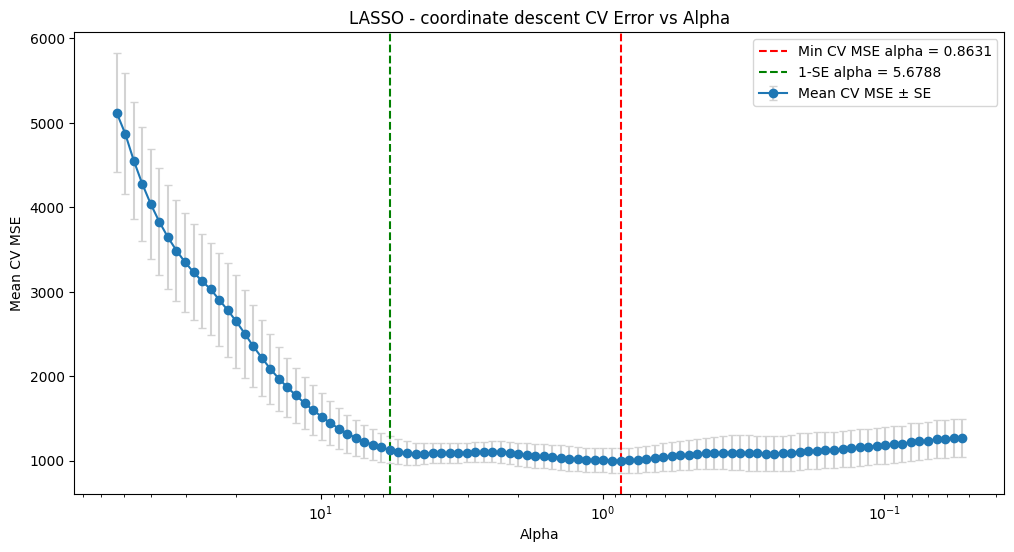

In [30]:
mse_path = lasso_final.mse_path_ 
mse_mean = np.mean(mse_path, axis=1)
mse_std = np.std(mse_path, axis=1) / np.sqrt(mse_path.shape[1])

min_idx = np.argmin(mse_mean)
min_mse = mse_mean[min_idx]
min_se = mse_std[min_idx]

threshold = min_mse + min_se

# find largest alpha with MSE <= threshold
alphas = lasso_final.alphas_
one_se_idx = np.where(mse_mean <= threshold)[0] 
alpha_1se = np.max(alphas[one_se_idx]) 

# coefs of 1se alpha
# refit on the full scaled data, coefs are not stored by lassolars cv
lasso_1se = Lasso(alpha=alpha_1se, fit_intercept=False)
lasso_1se.fit(X_scaled, y_centered)
coef_1se = lasso_1se.coef_
non_zero_1se = np.sum(coef_1se != 0)

print(f"Alpha chosen by 1 SE rule: {alpha_1se}")
print(f"Number of non-zero coefficients (1 SE): {non_zero_1se}")
print("\n")
print(f"Alpha chosen by min CV MSE: {best_alpha}")
print(f"Number of non-zero coefficients (min CV MSE): {non_zero_count}")


plt.figure(figsize=(12,6))
plt.errorbar(alphas, mse_mean, yerr=mse_std, fmt='-o', ecolor='lightgray', capsize=3,label='Mean CV MSE ± SE')
plt.axvline(best_alpha, color='red', linestyle='--',label=f'Min CV MSE alpha = {best_alpha:.4f}')
plt.axvline(alpha_1se, color='green', linestyle='--',label=f'1-SE alpha = {alpha_1se:.4f}')
plt.xlabel("Alpha")
plt.ylabel("Mean CV MSE")
plt.title("LASSO - coordinate descent CV Error vs Alpha")
plt.xscale('log')
plt.gca().invert_xaxis()
plt.legend()
plt.show()

In [31]:
# Boolean mask of selected features
selected_mask_1se = coef_1se != 0

# Get names of selected features
selected_features_1se = X.columns[selected_mask_1se]

# Get the corresponding coefficients
selected_coefs_1se = coef_1se[selected_mask_1se]

# Print feature names with coefficients
print("Features selected by LASSO 1-SE and their coefficients:")
for feat, coef in zip(selected_features_1se, selected_coefs_1se):
    print(f"{feat}: {coef:.4f}")

Features selected by LASSO 1-SE and their coefficients:
x_10: -5.7131
x_29: -1.6978
x_30: -4.3221
x_32: 50.2795
x_36: 16.9466
x_41: -1.2389
x_45: -2.8549
x_57: -0.3794
x_62: -20.2551
x_64: -0.3363
x_74: -2.4904


In [32]:
y_pred_min = X_scaled @ coef_final # alpha_min
mse_train_min = np.sqrt(np.mean((y_pred_min - y_centered)**2))

y_pred_1se = X_scaled @ coef_1se 
mse_train_1se = np.sqrt(np.mean((y_pred_1se - y_centered)**2))

print(f"Train MSE (min CV alpha): {mse_train_min:.4f}")
print(f"Train MSE (1 SE alpha): {mse_train_1se:.4f}")

Train MSE (min CV alpha): 14.6767
Train MSE (1 SE alpha): 30.4727


# Regression on new data

In [33]:
X_new = pd.read_csv("case1Data_Xnew.csv")

categorical_new = X_new[["C_01", "C_02", "C_03", "C_04", "C_05"]]
numerical_new = X_new.drop(columns=categorical_new.columns)

categorical_new = categorical_new.drop(columns="C_02")
categorical_new = categorical_new.fillna("missing")

categorical_new = pd.get_dummies(categorical_new)
categorical_new.columns = categorical_new.columns.str.replace(".0", "", regex=False)

categorical_new = categorical_new.reindex(columns=categorical_data.columns, fill_value=0)

numerical_new = numerical_new.fillna(numerical_data.median())

X_new_processed = pd.concat([numerical_new, categorical_new], axis=1)

In [34]:
X_new_scaled = X_new_processed.values.copy()
X_new_scaled[:, num_idx] = scaler.transform(X_new_scaled[:, num_idx])

In [35]:
y_pred_centered = X_new_scaled @ coef_1se

In [36]:
y_pred = y_pred_centered + mu

In [37]:
pred_df = pd.DataFrame(y_pred)
pred_df.to_csv(
    "predictions_s242906_s194564_s260478.csv", 
    index=False,   # no row index
    header=False   # no column header
)